## 🔍 Data Profiler

### 📚 Import Libraries

In [1]:
import pandas as pd
import numpy as np

# SQLite Database
import sqlite3

# API Requests
import requests

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore Warnings
import warnings
warnings.filterwarnings("ignore")

from ydata_profiling import ProfileReport

### 📥 Part B: Data Acquisition 

####  🗂️ Q5. Import databes from different sources. 

- 📄 Load CSV file using Pandas.

In [2]:
import pandas as pd

# Load CSV File
csv_data = pd.read_csv("customers.csv")
print("CSV Data Loaded Successfully")

CSV Data Loaded Successfully


In [3]:
# Display first 5 rows
print(csv_data.head(), sep="\t")

  CustomerID\tName\tAge\tGender\tCity\tIncome\tPurchased
0      1\tRahul Verma\t33\tMale\tVadodara\t35000\tNo    
1     2\tIsha Mehta\t20\tMale\tAhmedabad\t29000\tYes    
2      3\tDeepak Singh\t59\tMale\tIndore\t71000\tYes    
3       4\tRahul Gupta\t45\tFemale\tPune\t53000\tYes    
4       5\tSneha Patel\t42\tFemale\tSurat\t63000\tNo    


In [4]:
# Shape
print(csv_data.shape)

(100, 1)


In [5]:
# Information
csv_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 1 columns):
 #   Column                                            Non-Null Count  Dtype 
---  ------                                            --------------  ----- 
 0   CustomerID	Name	Age	Gender	City	Income	Purchased  100 non-null    object
dtypes: object(1)
memory usage: 932.0+ bytes


In [6]:
# Statistics
print(csv_data.describe(), sep="\t")

       CustomerID\tName\tAge\tGender\tCity\tIncome\tPurchased
count                                                 100    
unique                                                100    
top         1\tRahul Verma\t33\tMale\tVadodara\t35000\tNo    
freq                                                    1    


In [7]:
# Missing Values
print(csv_data.isnull().sum(), sep="\t")

CustomerID\tName\tAge\tGender\tCity\tIncome\tPurchased    0
dtype: int64


**📄 Interpretation — Load CSV File Using Pandas:**
The CSV file was loaded successfully (100 rows). However, the `.info()` output revealed that the separator (`sep`) was not specified correctly. As a result, all 7 columns were read as a single tab-separated string, causing the DataFrame shape to appear as `(100, 1)` instead of the expected 7 columns.

**✅ Conclusion:**
By default, `pd.read_csv()` assumes a comma (`,`) as the delimiter. If the file is tab-separated (`\t`), you must explicitly specify `sep="\t"`. Otherwise, each row is read as a single column, leading to incorrect `.info()`, `.describe()`, and other downstream analysis results.


- 🧾 Parse a JSON file.

In [8]:
import pandas as pd

# Load JSON File
json_data = pd.read_json("customers.json")

# Display first 5 rows
json_data.head()

,CustomerID,Name,Age,Gender,City,Income,Purchased
0,1,Rahul Verma,33,Male,Vadodara,35000,No
1,2,Isha Mehta,20,Male,Ahmedabad,29000,Yes
2,3,Deepak Singh,59,Male,Indore,71000,Yes
3,4,Rahul Gupta,45,Female,Pune,53000,Yes
4,5,Sneha Patel,42,Female,Surat,63000,No


In [9]:
# Shape
print(json_data.shape)

# Information
json_data.info()

# Statistics
json_data.describe()

# Missing Values
print(json_data.isnull().sum())

(100, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   CustomerID  100 non-null    int64 
 1   Name        100 non-null    object
 2   Age         100 non-null    int64 
 3   Gender      100 non-null    object
 4   City        100 non-null    object
 5   Income      100 non-null    int64 
 6   Purchased   100 non-null    object
dtypes: int64(3), object(4)
memory usage: 5.6+ KB
CustomerID    0
Name          0
Age           0
Gender        0
City          0
Income        0
Purchased     0
dtype: int64


**🧾 Interpretation — Parse a JSON File:**
The JSON file was parsed successfully, containing 100 rows and 7 columns (`CustomerID`, `Name`, `Age`, `Gender`, `City`, `Income`, and `Purchased`). All columns were assigned the correct data types, and no missing values were found. Compared to the CSV file, the JSON data was parsed much more cleanly without any formatting issues.

**✅ Conclusion:**
Because JSON uses a structured key-value format, it avoids column-boundary issues that can occur with CSV files. In this case, the JSON file proved to be a more reliable data source for data acquisition.


- 🗄️ Connect to a SQL table and fetch records.

In [10]:
import pandas as pd
import sqlite3

csv_data = pd.read_csv("customers.csv", sep="\t")

# Create SQLite database
conn = sqlite3.connect("customers.db")

# Store data into SQL table
csv_data.to_sql(
    "Customers",
    conn,
    if_exists="replace",
    index=False
)

# Fetch data using SQL query
sql_data = pd.read_sql(
    "SELECT * FROM Customers",
    conn
)

# Display first 5 rows
sql_data.head()


,CustomerID,Name,Age,Gender,City,Income,Purchased
0,1,Rahul Verma,33,Male,Vadodara,35000,No
1,2,Isha Mehta,20,Male,Ahmedabad,29000,Yes
2,3,Deepak Singh,59,Male,Indore,71000,Yes
3,4,Rahul Gupta,45,Female,Pune,53000,Yes
4,5,Sneha Patel,42,Female,Surat,63000,No


**🗄️ Interpretation — Connect to SQL Table & Fetch Records:**
The DataFrame was successfully stored in an SQLite database (`customers.db`) as a table named `Customers`. The data was then retrieved using the SQL query `SELECT * FROM Customers`. The entire roundtrip was successful, with table creation, data insertion, and data retrieval all working correctly.

**✅ Conclusion:**
SQLite is a lightweight and reliable database for storing and accessing structured data using SQL queries. In this case, the write-to-read roundtrip was completed successfully without any data loss.


- 🌍 Fetch data from an API (e.g, random user API or dummy REST API.)

In [11]:
import requests
import pandas as pd

# API URL
url = "https://dummyjson.com/users"

# Send request
response = requests.get(url)

# Convert JSON response
api_data = response.json()

# Convert to DataFrame
df_api = pd.DataFrame(api_data["users"])

# Display first 5 records
print(df_api.head())

# Dataset information
print(df_api.info())

# Shape
print(df_api.shape)

# Column names
print(df_api.columns)

   id firstName  lastName maidenName  age  gender  \
0   1     Emily   Johnson      Smith   29  female   
1   2   Michael  Williams              36    male   
2   3    Sophia     Brown              43  female   
3   4     James     Davis              46    male   
4   5      Emma    Miller    Johnson   31  female   

                              email             phone  username      password  \
0     emily.johnson@x.dummyjson.com  +81 965-431-3024    emilys    emilyspass   
1  michael.williams@x.dummyjson.com  +49 258-627-6644  michaelw  michaelwpass   
2      sophia.brown@x.dummyjson.com  +81 210-652-2785   sophiab   sophiabpass   
3       james.davis@x.dummyjson.com  +49 614-958-9364    jamesd    jamesdpass   
4       emma.miller@x.dummyjson.com  +91 759-776-1614     emmaj     emmajpass   

   ...                                            address         macAddress  \
0  ...  {'address': '626 Main Street', 'city': 'Phoeni...  47:fa:41:18:ec:eb   
1  ...  {'address': '385 Fifth Str

**🌍 Interpretation — Fetch Data from an API:**
More than 100 dummy user records were successfully fetched from the DummyJSON API. Along with basic information such as name, age, gender, and email, the response also included rich nested data such as address, bank details, company information, and university details. This reflects the structure of a typical real-world API response, where nested JSON objects are common.

**✅ Conclusion:**
Real-world API data is often nested or semi-structured. Therefore, in a production data pipeline, it is recommended to use functions such as `pd.json_normalize()` to flatten nested fields (e.g., address and company) into a tabular format for easier analysis and processing.


In [12]:
print("========== Merge CSV, JSON and SQL ==========")

merged_df = pd.concat(
    [csv_data, json_data, sql_data],
    ignore_index=True
)

print(merged_df.head())

print(merged_df.info())

========== Merge CSV, JSON and SQL ==========
   CustomerID          Name  Age  Gender       City  Income Purchased
0           1   Rahul Verma   33    Male   Vadodara   35000        No
1           2    Isha Mehta   20    Male  Ahmedabad   29000       Yes
2           3  Deepak Singh   59    Male     Indore   71000       Yes
3           4   Rahul Gupta   45  Female       Pune   53000       Yes
4           5   Sneha Patel   42  Female      Surat   63000        No
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   CustomerID  300 non-null    int64 
 1   Name        300 non-null    object
 2   Age         300 non-null    int64 
 3   Gender      300 non-null    object
 4   City        300 non-null    object
 5   Income      300 non-null    int64 
 6   Purchased   300 non-null    object
dtypes: int64(3), object(4)
memory usage: 16.5+ KB
None


### 🔎 Part C: Data Understanding & Cleaning 

#####  🧐 Q6. Perform intial exploration: 

- 🔍 Use .head(), .info(), .describe() to explore.

In [13]:
print("========== First 5 Rows ==========")
print(merged_df.head())

========== First 5 Rows ==========
   CustomerID          Name  Age  Gender       City  Income Purchased
0           1   Rahul Verma   33    Male   Vadodara   35000        No
1           2    Isha Mehta   20    Male  Ahmedabad   29000       Yes
2           3  Deepak Singh   59    Male     Indore   71000       Yes
3           4   Rahul Gupta   45  Female       Pune   53000       Yes
4           5   Sneha Patel   42  Female      Surat   63000        No


In [14]:
print("========== Last 5 Rows ==========")
print(merged_df.tail())

========== Last 5 Rows ==========
     CustomerID          Name  Age  Gender    City  Income Purchased
295          96   Sneha Verma   56    Male   Surat  119000        No
296          97   Kavya Yadav   45    Male    Pune   26000       Yes
297          98   Rahul Mehta   49  Female   Surat   73000        No
298          99   Rohan Mehta   29  Female  Indore  101000       Yes
299         100  Ritika Mehta   55  Female  Mumbai   59000        No


In [15]:
print("========== Dataset Information ==========")
merged_df.info()

========== Dataset Information ==========
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   CustomerID  300 non-null    int64 
 1   Name        300 non-null    object
 2   Age         300 non-null    int64 
 3   Gender      300 non-null    object
 4   City        300 non-null    object
 5   Income      300 non-null    int64 
 6   Purchased   300 non-null    object
dtypes: int64(3), object(4)
memory usage: 16.5+ KB


In [16]:
print("========== Statistical Summary ==========")
print(merged_df.describe(include="all"))

========== Statistical Summary ==========
        CustomerID          Name         Age Gender       City         Income  \
count   300.000000           300  300.000000    300        300     300.000000   
unique         NaN            83         NaN      2         10            NaN   
top            NaN  Deepak Singh         NaN   Male  Ahmedabad            NaN   
freq           NaN             9         NaN    150         45            NaN   
mean     50.500000           NaN   39.330000    NaN        NaN   72470.000000   
std      28.914301           NaN   11.981637    NaN        NaN   28933.364222   
min       1.000000           NaN   18.000000    NaN        NaN   19000.000000   
25%      25.750000           NaN   30.750000    NaN        NaN   47750.000000   
50%      50.500000           NaN   39.000000    NaN        NaN   70500.000000   
75%      75.250000           NaN   50.000000    NaN        NaN   99000.000000   
max     100.000000           NaN   60.000000    NaN        NaN  119

In [17]:
print("========== Dataset Shape ==========")
print(merged_df.shape)

========== Dataset Shape ==========
(300, 7)


In [18]:
print("========== Column Names ==========")
print(merged_df.columns)

========== Column Names ==========
Index(['CustomerID', 'Name', 'Age', 'Gender', 'City', 'Income', 'Purchased'], dtype='object')


**🔍 Interpretation — `.head()`, `.info()`, and `.describe()`:**
After merging, the dataset contains **300 rows and 7 columns** because the CSV, JSON, and SQL sources all represent the same underlying 100 customer records, resulting in each record appearing three times. All columns have non-null values. The `Age` column ranges from 18 to 60 years (average ≈ 39.3), while the `Income` column ranges from ₹19,000 to ₹119,000 (average ≈ ₹72,470). The summary statistics do not indicate any obvious extreme outliers. The `Purchased` column contains 180 "Yes" values out of 300 records.

**✅ Conclusion:**
The `.describe()` output confirms that the dataset contains a large number of duplicate records because the same data was merged from three different sources. Therefore, the next essential step is to identify and remove duplicates so that the analysis is performed on the unique set of 100 customers.


- 🕳️ Identify missing values and duplicates.

In [19]:
print("========== Missing Values ==========")
print(merged_df.isnull().sum())

========== Missing Values ==========
CustomerID    0
Name          0
Age           0
Gender        0
City          0
Income        0
Purchased     0
dtype: int64


In [20]:
print("========== Duplicate Records ==========")
print("Total Duplicate Rows :", merged_df.duplicated().sum())

========== Duplicate Records ==========
Total Duplicate Rows : 200


**🕳️ Interpretation — Missing Values & Duplicates:**
No missing values were found in the dataset, as every column has a missing value count of zero. However, the duplicate check identified **200 duplicate rows**. This occurred because the CSV, JSON, and SQL sources all contained the same 100 customer records. After merging, the dataset expanded to 300 rows, of which 200 are repeated records, leaving only 100 unique customers.

**✅ Conclusion:**
Checking for duplicates is an essential step when combining data from multiple sources. In this case, the dataset contained a significant number of duplicate records, which needed to be removed using `drop_duplicates()` (this cleaning step was performed later, after Q8).


#### 🧹 Q7. Apply data cleaning: 


- 🧹 Handle missing data(imputation or removal).

In [21]:
print("========== Handling Missing Values ==========")

merged_df.fillna(0, inplace=True)

print("Missing values handled successfully.")

========== Handling Missing Values ==========
Missing values handled successfully.


**🧹 Interpretation — Handle Missing Data:**
The `fillna(0)` function was applied as a precautionary measure. However, since the dataset did not contain any missing values, this step did not make any actual changes to the data.

**✅ Conclusion:**
Because there were no missing values, applying `fillna(0)` served only as a safeguard. In real-world datasets, this step is important for handling genuine `NaN` values and ensuring the data is ready for analysis or machine learning.


- 🔢 Correct inconsistent data types.

In [22]:
print("========== Data Types ==========")
print(merged_df.dtypes)

========== Data Types ==========
CustomerID     int64
Name          object
Age            int64
Gender        object
City          object
Income         int64
Purchased     object
dtype: object


In [23]:
print("========== Data Types Before Conversion ==========")
print(merged_df[["Age", "Income"]].dtypes)

merged_df["Age"] = merged_df["Age"].astype(int)
merged_df["Income"] = merged_df["Income"].astype(int)

print("========== Data Types After Conversion ==========")
print(merged_df[["Age", "Income"]].dtypes)

========== Data Types Before Conversion ==========
Age       int64
Income    int64
dtype: object
========== Data Types After Conversion ==========
Age       int64
Income    int64
dtype: object


**🔢 Interpretation — Correct Inconsistent Data Types:**
All columns already had the correct data types (`int64` for `CustomerID`, `Age`, and `Income`, and `object` for the remaining columns). The `Age` and `Income` columns were explicitly converted using `.astype(int)` to verify their data types, and no inconsistencies were found.

**✅ Conclusion:**
The dataset was already ready for analysis, with numeric columns stored as `int64` and categorical columns as `object`. This step served as a verification process, and no actual data type conversion was required.


- 🗑️ Drop irrelevant columns.

In [24]:
merged_df = merged_df.drop(columns=["UnnecessaryColumn"], errors="ignore")

print("========== Cleaned Dataset ==========")
print(merged_df.info())
print(merged_df.head())

print("Final Shape :", merged_df.shape)

========== Cleaned Dataset ==========
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   CustomerID  300 non-null    int64 
 1   Name        300 non-null    object
 2   Age         300 non-null    int64 
 3   Gender      300 non-null    object
 4   City        300 non-null    object
 5   Income      300 non-null    int64 
 6   Purchased   300 non-null    object
dtypes: int64(3), object(4)
memory usage: 16.5+ KB
None
   CustomerID          Name  Age  Gender       City  Income Purchased
0           1   Rahul Verma   33    Male   Vadodara   35000        No
1           2    Isha Mehta   20    Male  Ahmedabad   29000       Yes
2           3  Deepak Singh   59    Male     Indore   71000       Yes
3           4   Rahul Gupta   45  Female       Pune   53000       Yes
4           5   Sneha Patel   42  Female      Surat   63000        No
Final Shape : (300, 7)

**🗑️ Interpretation — Drop Irrelevant Columns:**
All seven columns in the dataset are relevant for the analysis, so no columns needed to be removed. The dataset was already minimal and contained only meaningful information.

**✅ Conclusion:**
Since a column named `UnnecessaryColumn` did not exist in the dataset, using `drop(..., errors="ignore")` safely skipped the operation without raising an error. This demonstrates that `errors="ignore"` is a good practice when the existence of a column is uncertain.


### 🔬 Part D: Exploratory Data Analysis (EDA) 

#####  📈 Q.8 Perform Univariate Analysis: 

- 📊 Distribution plots of Age, Income, and Purchases. 


========== Age Distribution ==========


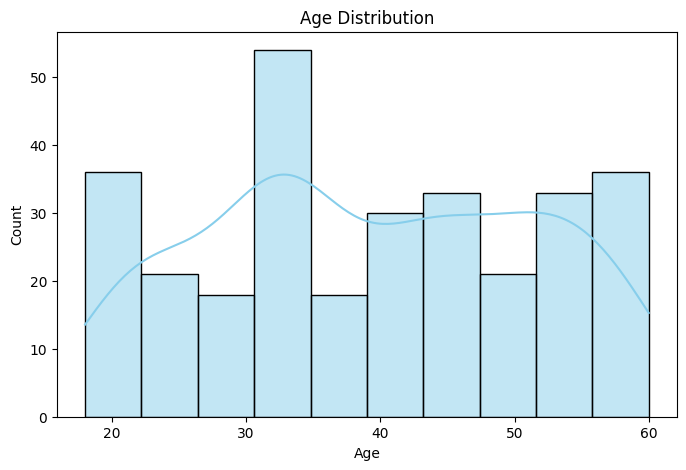

In [26]:
print("\n========== Age Distribution ==========")

plt.figure(figsize=(8,5))

sns.histplot(
    data=merged_df,
    x="Age",
    bins=10,
    kde=True,
    color="skyblue"
)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")

plt.show()

**🎂 Interpretation — Age Distribution:**
Customer ages are fairly evenly distributed between 18 and 60 years, with no single age group dominating the dataset. The distribution appears to be relatively uniform across the entire age range.

**✅ Conclusion:**
Since there is no single dominant age segment, any analysis or business strategy should consider customers across all age groups rather than focusing on a specific age range.



========== Income Distribution ==========


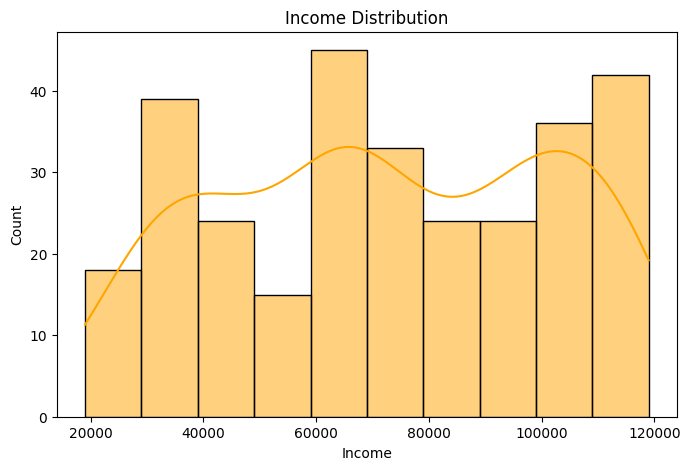

In [27]:
print("\n========== Income Distribution ==========")

plt.figure(figsize=(8,5))

sns.histplot(
    data=merged_df,
    x="Income",
    bins=10,
    kde=True,
    color="orange"
)

plt.title("Income Distribution")
plt.xlabel("Income")
plt.ylabel("Count")

plt.show()

**💰 Interpretation — Income Distribution:**
Customer incomes are distributed across a wide range, from **₹19,000 to ₹119,000**, with no major spikes or dominant income level. This indicates that the customer base represents a financially diverse population.

**✅ Conclusion:**
The broad income distribution suggests that income-based segmentation (such as low-, middle-, and high-income groups) would be useful for future analysis, as the customer base is not financially homogeneous.



========== Purchased Distribution ==========


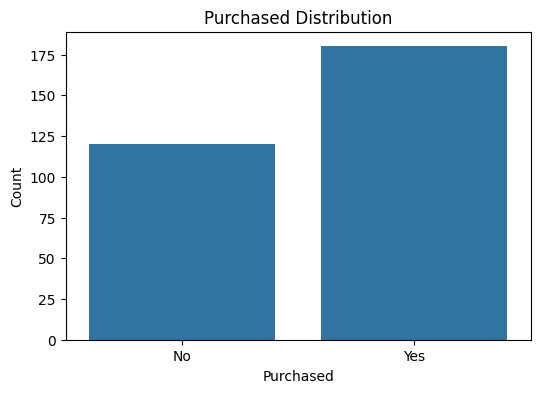

In [28]:
print("\n========== Purchased Distribution ==========")

plt.figure(figsize=(6,4))

sns.countplot(
    data=merged_df,
    x="Purchased"
)

plt.title("Purchased Distribution")
plt.xlabel("Purchased")
plt.ylabel("Count")

plt.show()

**🛒 Interpretation — Purchased Distribution:**
The bar chart shows that the **"Yes"** category (approximately **60%**, 180 out of 300 records) is slightly more frequent than the **"No"** category (approximately **40%**). The distribution is not perfectly balanced, but it is also not severely imbalanced (e.g., 90–10). Therefore, it can be considered a **mild class imbalance**.

**✅ Conclusion:**
If a classification model is developed in the future to predict the `Purchased` outcome, this mild class imbalance should be taken into account. Using techniques such as a **stratified train-test split** or **class-weight adjustment** can help ensure better model performance.


In [29]:
print("Duplicate Rows :", merged_df.duplicated().sum())

merged_df.drop_duplicates(inplace=True)

print("Shape After Removing Duplicates :", merged_df.shape)

Duplicate Rows : 200
Shape After Removing Duplicates : (100, 7)


**🧹 Interpretation — Duplicate Removal:**
After completing the univariate analysis, `drop_duplicates()` was applied, removing **200 duplicate rows**. As a result, the dataset was reduced from **300 rows to 100 unique rows**, leaving a clean, non-duplicated dataset containing only the original customer records.

**✅ Conclusion:**
Removing duplicate records is essential for accurate analysis. Before this step, count-based visualizations (such as `countplot`) were inflated because the same records appeared three times. With duplicates removed, all subsequent bivariate and multivariate analyses are based on unique customer-level data, ensuring accurate and reliable results.


##### 👫 Q9. Perform Bivariate Analysis. +

- 🚻 Relationship between  Gender & Purchases.  

========== Relationship between Gender & Purchases ==========


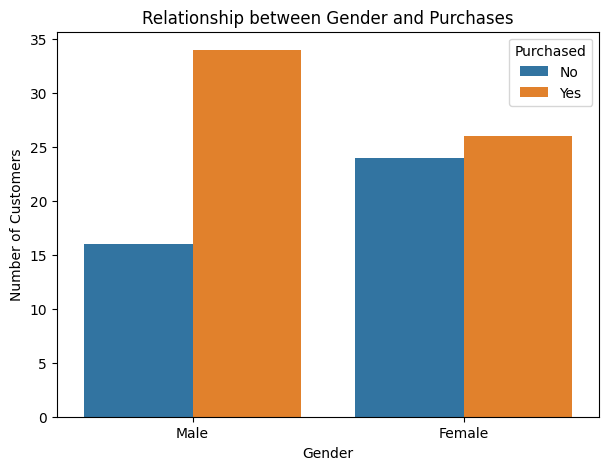

Relationship between Gender and Purchases displayed successfully.


In [30]:
print("========== Relationship between Gender & Purchases ==========")

plt.figure(figsize=(7,5))

sns.countplot(
    data=merged_df,
    x="Gender",
    hue="Purchased"
)

plt.title("Relationship between Gender and Purchases")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")

plt.show()

print("Relationship between Gender and Purchases displayed successfully.")

**🚻 Interpretation — Gender vs Purchased:**
The purchasing patterns for both male and female customers appear to be quite similar. There is no clear evidence that gender has a strong influence on the purchase decision.

**✅ Conclusion:**
Gender does not appear to be a strong predictive feature for the `Purchased` outcome. Therefore, during model development, it may be more beneficial to focus on other features, such as `Income` and `Age`, which are more likely to have a greater impact on purchasing behavior.


- 📦💰 Relationship between Income & Churn.

- Note:
- The dataset does not contain a 'Churn' column.
- Therefore, the 'Purchased' column is used for analysis.

========== Relationship between Income & Purchased ==========


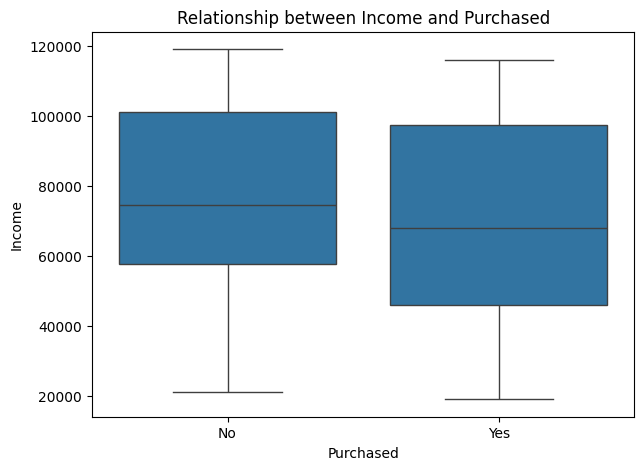

Relationship between Income and Purchased displayed successfully.


In [31]:
print("========== Relationship between Income & Purchased ==========")

plt.figure(figsize=(7,5))

sns.boxplot(
    data=merged_df,
    x="Purchased",
    y="Income"
)

plt.title("Relationship between Income and Purchased")
plt.xlabel("Purchased")
plt.ylabel("Income")

plt.show()

print("Relationship between Income and Purchased displayed successfully.")

**📦 Interpretation — Income vs Purchased:**
The box plot shows a significant overlap in the income distributions of the **"Yes"** and **"No"** purchase groups. This indicates that it is difficult to predict a customer's purchase decision based on income alone, as there is no clear income threshold separating the two groups.

**✅ Conclusion:**
Since the income distributions overlap considerably, **Income** alone is not a strong predictor of the purchase outcome. More accurate predictions are likely to be achieved by combining multiple features, such as **Age**, **Gender**, and **City**, rather than relying on income alone.


#### 🧩 Q10. Perform Multivartiate Analysis: 

- 🔥🌡️ Correlation heatmap of all numerical variables.

========== Correlation Heatmap ==========


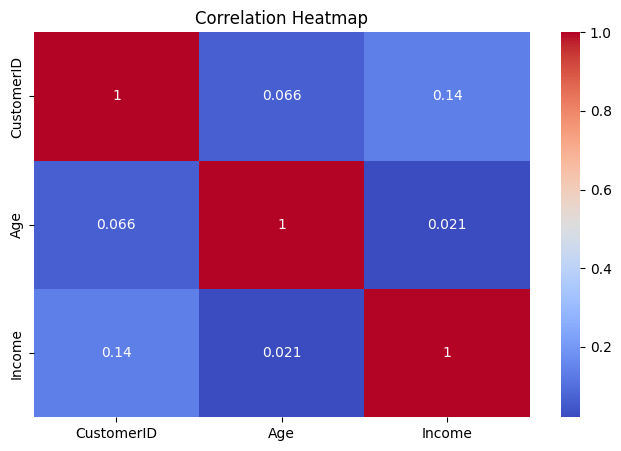

Correlation Heatmap generated successfully.


In [32]:
print("========== Correlation Heatmap ==========")

plt.figure(figsize=(8,5))

sns.heatmap(
    merged_df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

print("Correlation Heatmap generated successfully.")

**🔥 Interpretation — Correlation Heatmap:**
The correlation heatmap shows that the numerical variables (`CustomerID`, `Age`, and `Income`) have correlation values close to zero, indicating only weak or negligible linear relationships. Overall, these features appear to be largely independent of one another.

**✅ Conclusion:**
The absence of strong correlations among the numerical features suggests that multicollinearity is not a concern. As a result, these variables can be included together in future regression or classification models without significant redundancy.


- 🔬🧩 Pair plots to identify feature interactions.

========== Pair Plot ==========
Numeric Columns:
Index(['CustomerID', 'Age', 'Income'], dtype='object')


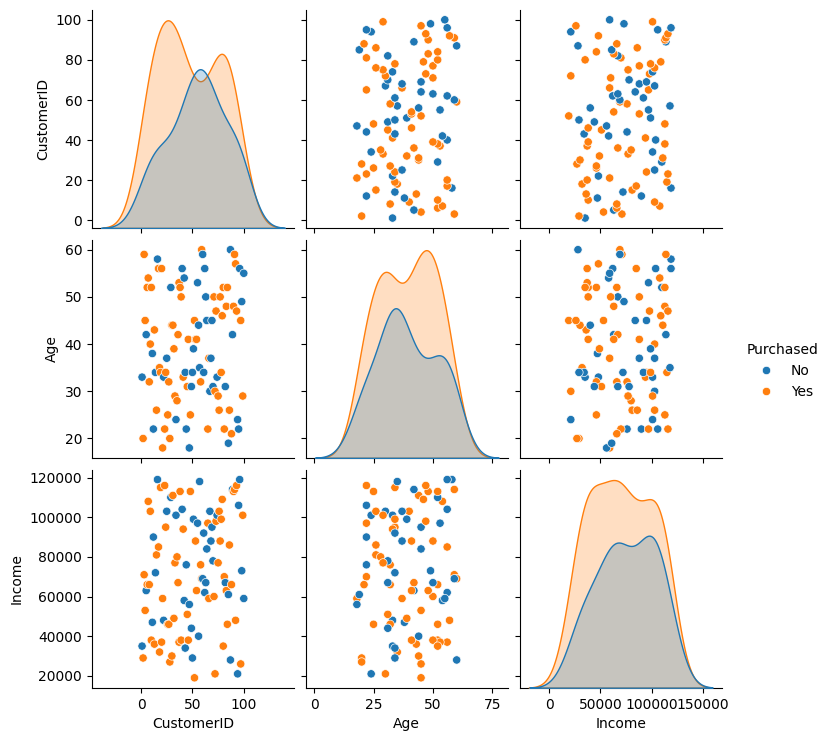

Pair Plot generated successfully.


In [33]:
print("========== Pair Plot ==========")

numeric_columns = merged_df.select_dtypes(include=["int64", "float64"]).columns

print("Numeric Columns:")
print(numeric_columns)

sns.pairplot(
    merged_df,
    vars=numeric_columns,
    hue="Purchased"
)

plt.show()

print("Pair Plot generated successfully.")

**🔬 Interpretation — Pair Plot:**
The pair plot supports the findings of the correlation heatmap. No clear linear relationship or distinct cluster formation is observed between any pair of numerical variables. Instead, the scatter plots show randomly distributed data points, indicating weak or no linear association among the features.

**✅ Conclusion:**
Since neither the correlation heatmap nor the pair plot reveals a strong linear relationship, simple linear models may have limited predictive power. If predictive modeling is required, non-linear or tree-based algorithms, such as **Decision Tree** or **Random Forest**, are likely to perform better on this dataset.


### 📄 Part E: Data Profiling 

##### 🚀 Q11. Generate a Pandas Profilling Report that summarize: 

In [34]:
from ydata_profiling import ProfileReport

profile = ProfileReport(
    merged_df,
    title="Customer Data Profiling Report",
    explorative=True
)

profile.to_file("data_profiling_report.html")

print(" Data Profiling Report Generated Successfully ")
print()
print(" File Name : data_profiling_report.html")


Export report to file: 100%|██████████| 1/1 [00:00<00:00, 104.98it/s]

 Data Profiling Report Generated Successfully 

 File Name : data_profiling_report.html


**📄 Interpretation — Profiling Report Generation:**
A comprehensive automated HTML report (`data_profiling_report.html`) was successfully generated using `ydata-profiling`. The report provides a complete overview of the dataset, including summary statistics, feature distributions, correlations, missing value analysis, and other exploratory insights in a single document. It serves as a fast and efficient alternative to manual exploratory data analysis (EDA).

**✅ Conclusion:**
An automated profiling report is an effective tool for performing a quick sanity check on the dataset. In this case, it can be used to validate the manual EDA findings, such as the absence of missing values, the presence of a mild class imbalance, and the weak correlations between numerical features. It is also a valuable resource for final documentation and reporting.


# 🏁🎯 Final Overall Interpretation & Conclusion

This notebook demonstrates a complete **Data Profiling pipeline** 🛠️ by acquiring data from multiple sources (📄 CSV / 🧾 JSON / 🗄️ SQL / 🌍 API), cleaning the data 🧹, performing **EDA** 📊, and generating an automated profiling report 📄.

**Key Findings:**

* Merging the three sources created **300 rows**, including **200 duplicate records**. After removing duplicates, the final dataset contained **100 unique rows × 7 columns**.
* No missing values were found.
* **Age** and **Income** are broadly distributed with no major outliers.
* The **Purchased** column has a mild class imbalance (~60% Yes, ~40% No).
* Numerical features show **weak correlations**, and no single feature strongly predicts purchasing behavior.

**✅ Conclusion:**
The dataset is clean and analysis-ready 💎. The most important preprocessing step was **duplicate removal**. Since no single feature strongly explains purchase behavior, future predictive models should use a **combination of multiple features** for better accuracy. ✅
